# Session 9 — Research Ethics in AI
## Hands-on Lab: “When fairness fights itself” — the COMPAS impossibility theorem

**UNMSM Doctoral Program in Deep Technologies · Dr. Loveleen Gaur**

---

### Why this lab exists
In the lecture we met **COMPAS**: ProPublica said it was *biased against Black defendants*; the vendor (Northpointe) said it was *fair*. The unsettling part is that **both were mathematically correct**. This notebook lets you reproduce that result on the **real, public ProPublica dataset** and feel, in your own hands, why:

> *Choosing a fairness metric is a moral choice, not a purely technical one.* (Belmont **Justice** principle in action.)

### What you will do
1. Load the real ProPublica COMPAS data (no fabricated numbers — you compute everything live).
2. Reproduce **ProPublica's** view: false-positive rates differ sharply by race.
3. Reproduce **Northpointe's** view: predictive parity (PPV) is roughly equal by race.
4. Watch the two definitions **trade off** — you cannot zero both gaps at once.
5. Connect the result back to your **ethics protocol**.

### Scope note
This is the **ethics** lab: it shows *why* the choice of fairness definition is value-laden. It is **not** a mitigation tutorial — measuring and *correcting* bias with AIF360 / Fairlearn is the hands-on for **Session 11**.

### Estimated time: 30–40 minutes (runs entirely in the browser; no install needed in Colab).


## Part 0 — Setup
All libraries below ship with Google Colab. Just run the cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
np.random.seed(42)  # determinism is part of reproducible, accountable research
print('Environment ready.')

Environment ready.


## Part 1 — Load the real ProPublica COMPAS data
We pull the canonical file straight from ProPublica's public analysis repository. Citing your data source is itself an ethics practice (provenance & transparency).

*Source:* Angwin, J., Larson, J., Mattu, S., & Kirchner, L. (2016). *Machine Bias.* ProPublica. Dataset: `propublica/compas-analysis` (GitHub).

In [2]:
URL = ('https://raw.githubusercontent.com/propublica/'
       'compas-analysis/master/compas-scores-two-years.csv')
df = pd.read_csv(URL)
print('Loaded rows, columns:', df.shape)
df[['sex','race','age','priors_count','decile_score',
    'score_text','two_year_recid']].head()

Loaded rows, columns: (7214, 53)


    sex              race  age  ...  decile_score  score_text two_year_recid
0  Male             Other   69  ...             1         Low              0
1  Male  African-American   34  ...             3         Low              1
2  Male  African-American   24  ...             4         Low              1
3  Male  African-American   23  ...             8        High              0
4  Male             Other   43  ...             1         Low              0

[5 rows x 7 columns]

### Reflect (Respect for Persons)
Every row is a real person who was scored by an algorithm that influenced their pretrial liberty. They did not consent to becoming a benchmark. Hold that in mind as you compute.

## Part 2 — Reproduce ProPublica's preprocessing
Transparent preprocessing is an ethics requirement: a reviewer must be able to see *exactly* which rows you kept and why. We apply ProPublica's published filters and bin the 1–10 risk score into **Low (1–4)** vs **High (5–10)**, and restrict to the two largest groups so the comparison is clean.

In [3]:
d = df[(df.days_b_screening_arrest <= 30) &
       (df.days_b_screening_arrest >= -30) &
       (df.is_recid != -1) &
       (df.c_charge_degree != 'O') &
       (df.score_text != 'N/A')].copy()

d = d[d.race.isin(['African-American', 'Caucasian'])].copy()

# Predicted label: was the person flagged High-risk?  (decile 5-10)
d['high_risk'] = (d.decile_score >= 5).astype(int)
# Ground truth: did they actually reoffend within 2 years?
d['recid'] = d.two_year_recid.astype(int)

print('Analysis rows:', len(d))
print(d.groupby('race').size())

Analysis rows: 5278
race
African-American    3175
Caucasian           2103
dtype: int64


## Part 3a — ProPublica's lens: false-positive rate by race
A **false positive** here is a person labelled *High-risk* who did **not** reoffend — i.e., someone the system wronged. ProPublica argued the system is unfair because this error is not shared equally.

In [4]:
def confusion(group):
    tp = ((group.high_risk==1) & (group.recid==1)).sum()
    fp = ((group.high_risk==1) & (group.recid==0)).sum()
    tn = ((group.high_risk==0) & (group.recid==0)).sum()
    fn = ((group.high_risk==0) & (group.recid==1)).sum()
    fpr = fp / (fp + tn)            # flagged high | actually did NOT reoffend
    fnr = fn / (fn + tp)            # flagged low  | actually DID reoffend
    ppv = tp / (tp + fp)            # of those flagged high, share who reoffended
    base = (tp + fn) / len(group)  # base recidivism rate in the group
    return dict(N=len(group), FPR=fpr, FNR=fnr, PPV=ppv, base_rate=base)

rows = {r: confusion(d[d.race==r]) for r in ['African-American','Caucasian']}
summary = pd.DataFrame(rows).T
for c in ['FPR','FNR','PPV','base_rate']:
    summary[c] = (summary[c]*100).round(1)
summary['N'] = summary['N'].astype(int)
summary

                     N   FPR   FNR   PPV  base_rate
African-American  3175  42.3  28.5  65.0       52.3
Caucasian         2103  22.0  49.6  59.5       39.1

Black false-positive rate is about 1.9x the white rate.


<notebook>:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


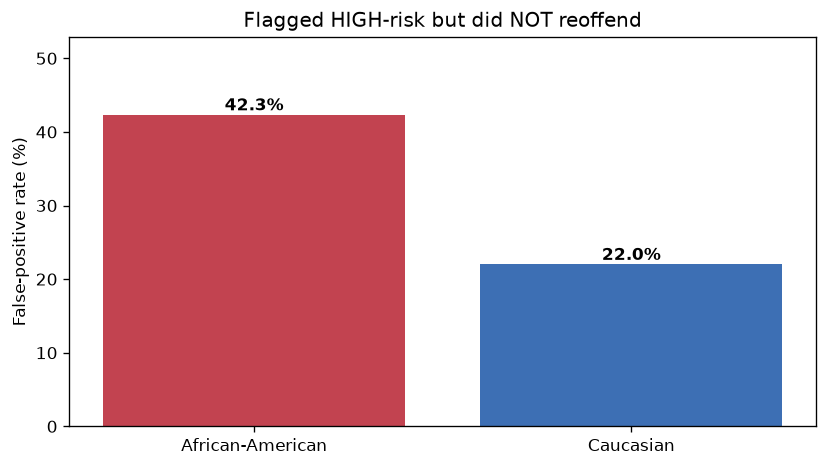

In [5]:
# Visualize the false-positive gap (ProPublica's headline)
groups = ['African-American','Caucasian']
fpr_vals = [rows[g]['FPR']*100 for g in groups]

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(groups, fpr_vals, color=['#C24350','#3D6FB4'])
ax.set_ylabel('False-positive rate (%)')
ax.set_title('Flagged HIGH-risk but did NOT reoffend')
for b,v in zip(bars,fpr_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.6, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylim(0, max(fpr_vals)*1.25)
plt.tight_layout(); plt.show()

ratio = fpr_vals[0]/fpr_vals[1]
print(f'Black false-positive rate is about {ratio:.1f}x the white rate.')

> **What you should see:** the false-positive rate for Black defendants is roughly **twice** that of white defendants. This is ProPublica's core claim — reproduced live, not quoted.

## Part 3b — Northpointe's lens: predictive parity (PPV)
Northpointe defended COMPAS on a *different* definition: among everyone flagged High-risk, the share who actually reoffend (**positive predictive value**) should be about the same across groups. Check it.

PPV gap between groups: 5.5 percentage points (small).


<notebook>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


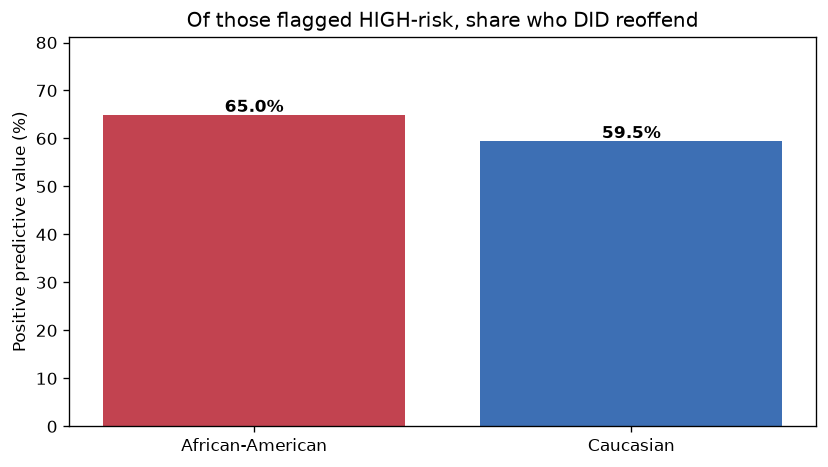

In [6]:
ppv_vals = [rows[g]['PPV']*100 for g in groups]

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(groups, ppv_vals, color=['#C24350','#3D6FB4'])
ax.set_ylabel('Positive predictive value (%)')
ax.set_title('Of those flagged HIGH-risk, share who DID reoffend')
for b,v in zip(bars,ppv_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.6, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylim(0, max(ppv_vals)*1.25)
plt.tight_layout(); plt.show()

print(f'PPV gap between groups: {abs(ppv_vals[0]-ppv_vals[1]):.1f} percentage points (small).')

> **What you should see:** PPV is roughly **equal** across groups. By *this* definition, COMPAS looks fair. Northpointe was not lying — they simply chose a different fairness metric.

## Part 3c — Both are true at once: the impossibility theorem
You have now reproduced two correct, contradictory conclusions from the *same data and same model*. This is not a bug. When **base recidivism rates differ between groups**, it is mathematically impossible to satisfy *equal error rates* (ProPublica) and *equal predictive value / calibration* (Northpointe) **simultaneously**.

- Chouldechova, A. (2017). *Fair prediction with disparate impact.* Big Data, 5(2), 153–163.
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2017). *Inherent trade-offs in the fair determination of risk scores.* ITCS.

Confirm the base rates differ — that difference is *why* the two metrics cannot both hold:

In [7]:
print('Base recidivism rate by group (from the data):')
for g in groups:
    print(f'  {g:18s}: {rows[g]["base_rate"]*100:.1f}%')
print('\nUnequal base rates => equal-error-rate and equal-PPV cannot both hold.')

Base recidivism rate by group (from the data):
  African-American  : 52.3%
  Caucasian         : 39.1%

Unequal base rates => equal-error-rate and equal-PPV cannot both hold.


## Part 4 — You decide the threshold: who bears the error?
There is no neutral default. Move the High-risk cutoff and watch the **two fairness gaps move in opposite directions**. Try cutoffs of 3, 5, 7. You are not finding the ‘right’ number — you are choosing *whose* error to minimize.

<notebook>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


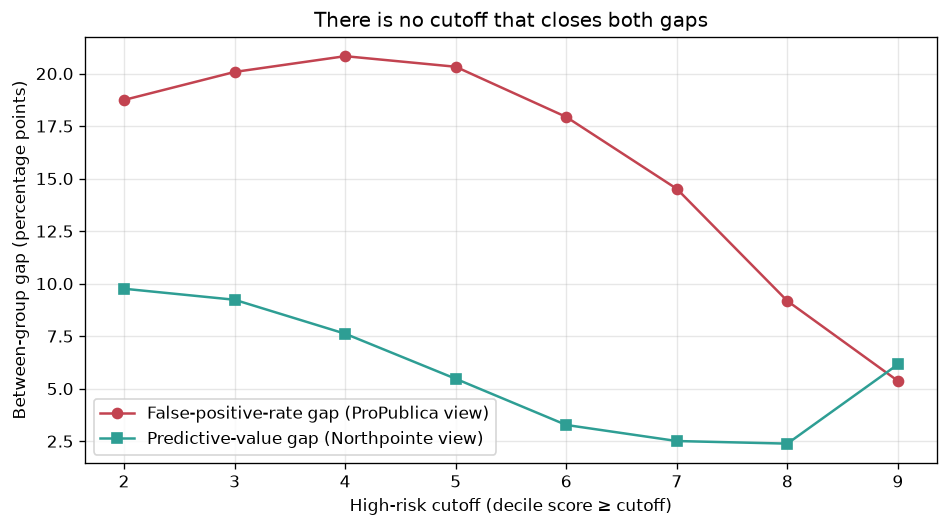

In [8]:
def gaps_at(cutoff):
    t = d.copy()
    t['high_risk'] = (t.decile_score >= cutoff).astype(int)
    out = {}
    for g in groups:
        out[g] = confusion(t[t.race==g])
    fpr_gap = abs(out[groups[0]]['FPR'] - out[groups[1]]['FPR'])*100
    ppv_gap = abs(out[groups[0]]['PPV'] - out[groups[1]]['PPV'])*100
    return fpr_gap, ppv_gap

cutoffs = list(range(2, 10))
fpr_gaps = [gaps_at(c)[0] for c in cutoffs]
ppv_gaps = [gaps_at(c)[1] for c in cutoffs]

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(cutoffs, fpr_gaps, marker='o', color='#C24350', label='False-positive-rate gap (ProPublica view)')
ax.plot(cutoffs, ppv_gaps, marker='s', color='#2E9E94', label='Predictive-value gap (Northpointe view)')
ax.set_xlabel('High-risk cutoff (decile score ≥ cutoff)')
ax.set_ylabel('Between-group gap (percentage points)')
ax.set_title('There is no cutoff that closes both gaps')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Reflect (Belmont **Justice**)
- When you lower the cutoff to catch more true reoffenders, whose false-positive rate rises fastest?
- A judge using this tool never sees these curves. **Whose responsibility is the trade-off you just made?**
- Write one sentence: which metric would *you* prioritize for a pretrial tool, and why? (There is no free answer.)

In [9]:
# Reasoned fairness choice for the pretrial COMPAS example:
my_choice = (
    'Equal false-positive rates, because wrongful high-risk classification can '
    'restrict liberty and that burden should not fall disproportionately on one group.'
)
assert my_choice.strip() != '', 'Write your reasoned choice before continuing.'
print('Recorded:', my_choice)


Recorded: Equal false-positive rates, because wrongful high-risk classification can restrict liberty and that burden should not fall disproportionately on one group.


## Part 5 — From audit to protocol (the Cusco bridge)
Recall the debate: deploying a Lima-trained deterioration model in rural **Cusco**. The COMPAS lesson generalizes — a model can be *calibrated* overall yet impose unequal error on a subgroup, and **distribution shift** (different population, equipment, disease profile) makes this worse and harder to see.

Turn the lesson into protocol language. Fill the dictionary, then run the completeness check.

In [10]:
# Ethics commitments transferred from the COMPAS exercise to AI-DOTS:
ethics_protocol = {
    'population_and_subgroups': (
        'Adults aged 18 or older, without active tuberculosis, who already take oral '
        'medication daily for a non-contagious condition; evaluate lighting, occlusion, '
        'camera angle, device, and setting without collecting unjustified sensitive data.'
    ),
    'fairness_metric_chosen': (
        'Prioritize control and reporting of false-positive ingestion validation across '
        'technical conditions, because falsely confirming a dose may conceal non-ingestion; '
        'also report false negatives, precision, recall, calibration, and uncertainty.'
    ),
    'who_bears_the_error': (
        'Participants bear the harm: false positives create unsafe reassurance, while false '
        'negatives may cause stigma, repeated recording, or punitive follow-up.'
    ),
    'distribution_shift_plan': (
        'Re-evaluate by pill brand, phone, lighting, angle, occlusion, and urban/rural setting; '
        'pause use when pre-specified thresholds are breached and require revalidation.'
    ),
    'consent_and_data_basis': (
        'Written informed consent and prior favorable UNMSM CEI opinion; comply with Peru Law '
        '29733 and DS 016-2024-JUS; record hands, pill, and lower face only, with audio disabled.'
    ),
    'dual_use_risk': (
        'Prohibit covert surveillance, punitive adherence enforcement, identity recognition, '
        'employment or insurance decisions, and unrelated biometric-model training.'
    ),
    'monitoring_and_redress': (
        'No automated adverse action; require trained human review, incident monitoring, '
        'participant access/correction/deletion channels, and an appeal pathway.'
    ),
}

def completeness(p):
    done = [k for k,v in p.items() if str(v).strip()]
    missing = [k for k,v in p.items() if not str(v).strip()]
    pct = round(100*len(done)/len(p))
    print(f'Protocol completeness: {pct}%  ({len(done)}/{len(p)} sections)')
    if missing:
        print('Still to write:')
        for m in missing: print('   -', m.replace('_',' '))
    else:
        print('All core ethics sections drafted. Bring this to the workshop block.')

completeness(ethics_protocol)


Protocol completeness: 100%  (7/7 sections)
All core ethics sections drafted. Bring this to the workshop block.


## Part 6 — What to hand in
1. This notebook, **run top to bottom** (so the figures and your numbers are visible).
2. Your one-sentence fairness choice from Part 4.
3. Your `ethics_protocol` dictionary at ≥ 80% completeness — it seeds the ethics chapter of your thesis.

### Key takeaways
- *Fair* has **multiple incompatible definitions**; a model can satisfy one and violate another.
- Under unequal base rates, **you must choose** — and the choice is an ethical, not a technical, act.
- A ‘neutral’ model still distributes error. **Name who bears it** in your protocol.

---
### References
- Angwin, J., Larson, J., Mattu, S., & Kirchner, L. (2016). *Machine Bias.* ProPublica.
- Chouldechova, A. (2017). *Fair Prediction with Disparate Impact.* Big Data, 5(2), 153–163.
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2017). *Inherent Trade-Offs in the Fair Determination of Risk Scores.* ITCS.
- Obermeyer, Z., Powers, B., Vogeli, C., & Mullainathan, S. (2019). *Dissecting racial bias in an algorithm used to manage the health of populations.* Science, 366(6464), 447–453.
- National Commission (1979). *The Belmont Report.* U.S. DHEW.
- Dittrich, D., & Kenneally, E. (2012). *The Menlo Report.* U.S. DHS.

*Note on numbers:* exact percentages depend on the published preprocessing choices; your live values match ProPublica's qualitative finding (Black false-positive rate ≈ 2× white, with similar predictive value across groups).